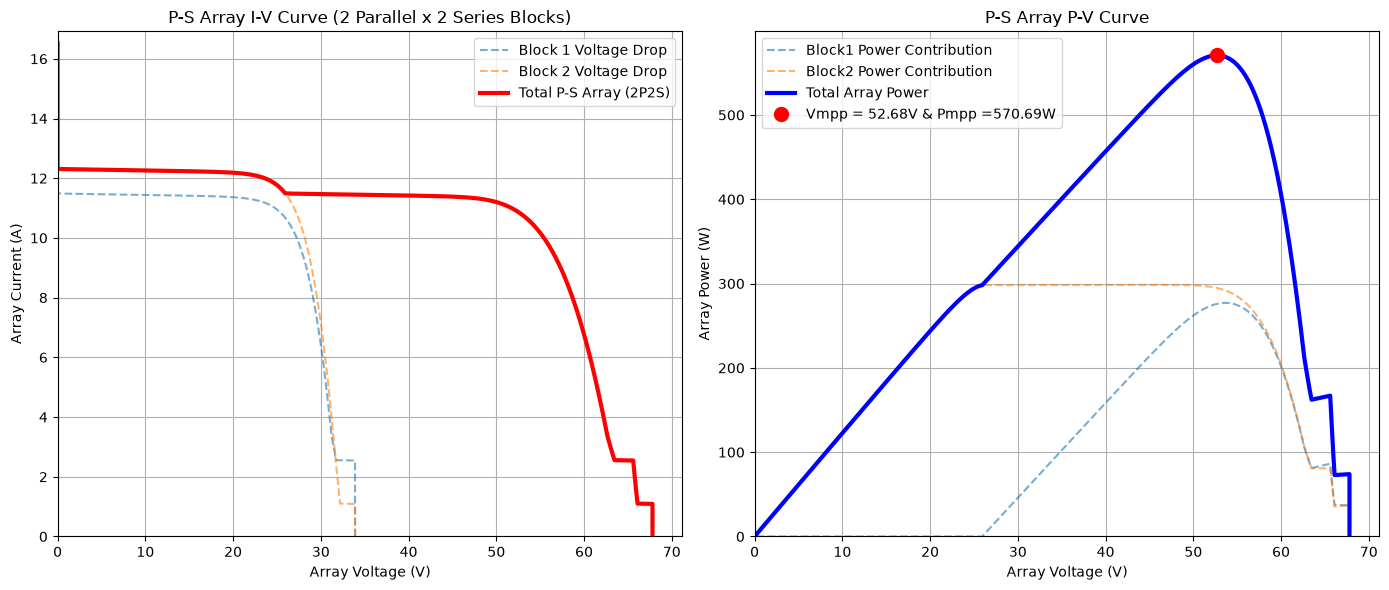

In [1]:
import numpy as np
import matplotlib.pyplot as plt

k = 1.38e-23  
q = 1.60e-19  

Isc = 8.21    
Voc = 32.9
Ns = 54     
Kv = -0.123 
Ki = 0.0032         
n = 1.3             

Rsh = 415.405      
Rs = 0.221        
Ion = 9.825e-8   

T= 25 + 273.15   
Vt = (Ns * k * T) / q  

def solve_module_current(V, G):
    I_pv = (Isc + Ki * (T- 298.15)) * (G / 1000)
    I_o = Ion * ((T / 298.15)**3) * np.exp(((q * 1.12) / (n * k)) * (1/298.15 - 1/T))
    
    i_guess = I_pv
    for _ in range(10):
       
        i_guess = I_pv - I_o *  (np.exp((V + i_guess * Rs) / (n * Vt)) - 1 )-   (V + i_guess * Rs) / Rsh
    return max(0, i_guess)

N_par = 2  # 2 modules connected in parallel to form a block
N_ser = 2  # then 2 such blocks are connected in seies

irradiance_matrix = np.array([ [1000, 400],  
                               [700,  800],  ])

max_possible_current = N_par * Isc
I_array = np.linspace(0, max_possible_current + 0.1, 1500)

V_array_total = np.zeros_like(I_array)

block_voltages = [np.zeros_like(I_array) for _ in range(N_ser)]

for idx, I_target in enumerate(I_array):
    
    for block_idx in range(N_ser):
        G_levels= irradiance_matrix[block_idx] 
        
        v_low = 0.0
        v_high = Voc + 1.0
        v_block = 0.0
        
        for _ in range(50): 
            v_mid = (v_low + v_high) / 2
            
            I_block_sum = sum(solve_module_current(v_mid, G) for G in G_levels)
            
            if I_block_sum > I_target:
                v_low = v_mid  
                v_block = v_mid
            else:
                v_high = v_mid 
                
        block_voltages[block_idx][idx] = v_block

for block_v in block_voltages:
    V_array_total += block_v

P_array_total = V_array_total * I_array

idx_mpp = np.argmax(P_array_total)
V_mpp = V_array_total[idx_mpp]
I_mpp = I_array[idx_mpp]
P_mpp = P_array_total[idx_mpp]




plt.figure(figsize=(14, 6))

# I-V Characteristics
plt.subplot(1, 2, 1)
for block_idx in range(N_ser):
    plt.plot(block_voltages[block_idx], I_array, '--', label=f'Block {block_idx+1} Voltage Drop', alpha=0.6)

plt.plot(V_array_total, I_array, 'r', linewidth=3, label=f'Total P-S Array ({N_par}P{N_ser}S)')
plt.title(f'P-S Array I-V Curve ({N_par} Parallel x {N_ser} Series Blocks)')
plt.xlabel('Array Voltage (V)')
plt.ylabel('Array Current (A)')
plt.grid(True)
plt.legend()
plt.xlim(left=0)
plt.ylim(0, max_possible_current + 0.5)

# P-V Characteristics
plt.subplot(1, 2, 2)
for block_idx in range(N_ser):
    P_block = block_voltages[block_idx] * I_array
    plt.plot(V_array_total, P_block , '--', label=f'Block{block_idx+1} Power Contribution', alpha=0.6)

plt.plot(V_array_total, P_array_total, 'b', linewidth=3, label='Total Array Power')
plt.plot(V_mpp, P_mpp, 'ro', markersize=10, label=f'Vmpp = {V_mpp:.2f}V & Pmpp ={P_mpp:.2f}W')

plt.title('P-S Array P-V Curve')
plt.xlabel('Array Voltage (V)')
plt.ylabel('Array Power (W)')
plt.grid(True)
plt.legend()
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()